<a href="https://colab.research.google.com/github/AngellyC07/Ciencia_de_datos/blob/main/tabajando_medidas_centrales_(TAREAS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Trabajamos con dataframes

In [ ]:
!pip install statsmodels

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
estado = pd.read_csv("/content/state.csv")

In [ ]:
estado.shape

(50, 4)

#Diagramas vistos por el momento
1. Histograma
2. Densidad

In [ ]:
estado.head()

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


In [ ]:
estado["Population"].mean()

np.float64(6162876.3)

<Axes: >

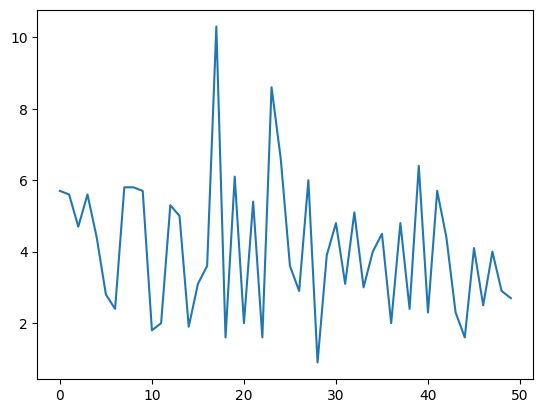

In [ ]:
estado['Murder.Rate'].plot()

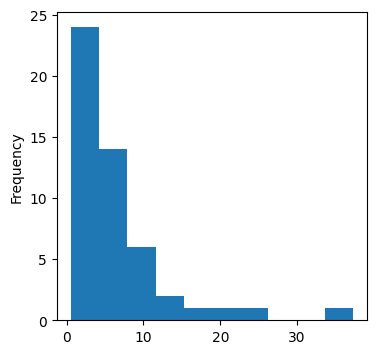

In [ ]:
ax=(estado.Population/1_000_000).plot.hist(figsize=(4,4))
ax.set_label("Population[millón]")

plt.tight_layout
plt.show()

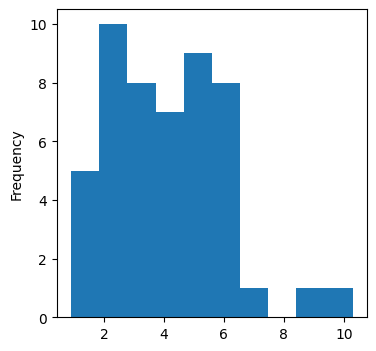

In [ ]:
ax=(estado["Murder.Rate"]).plot.hist(figsize=(4,4))
ax.set_label("Tasa de asesinatos por estado")

plt.tight_layout
plt.show()

#TAREA 1 RESPUESTA

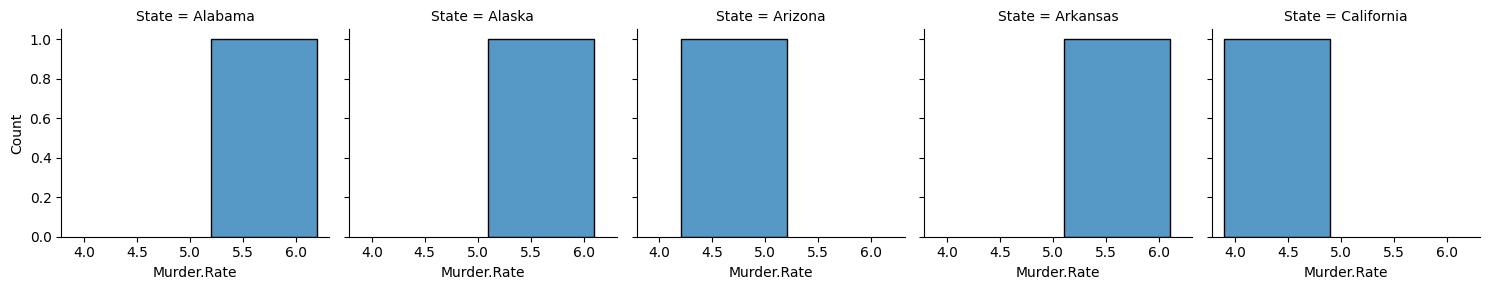

In [ ]:
analisis = estado.head()
g = sns.FacetGrid(analisis, col="State")
g.map(sns.histplot, "Murder.Rate")

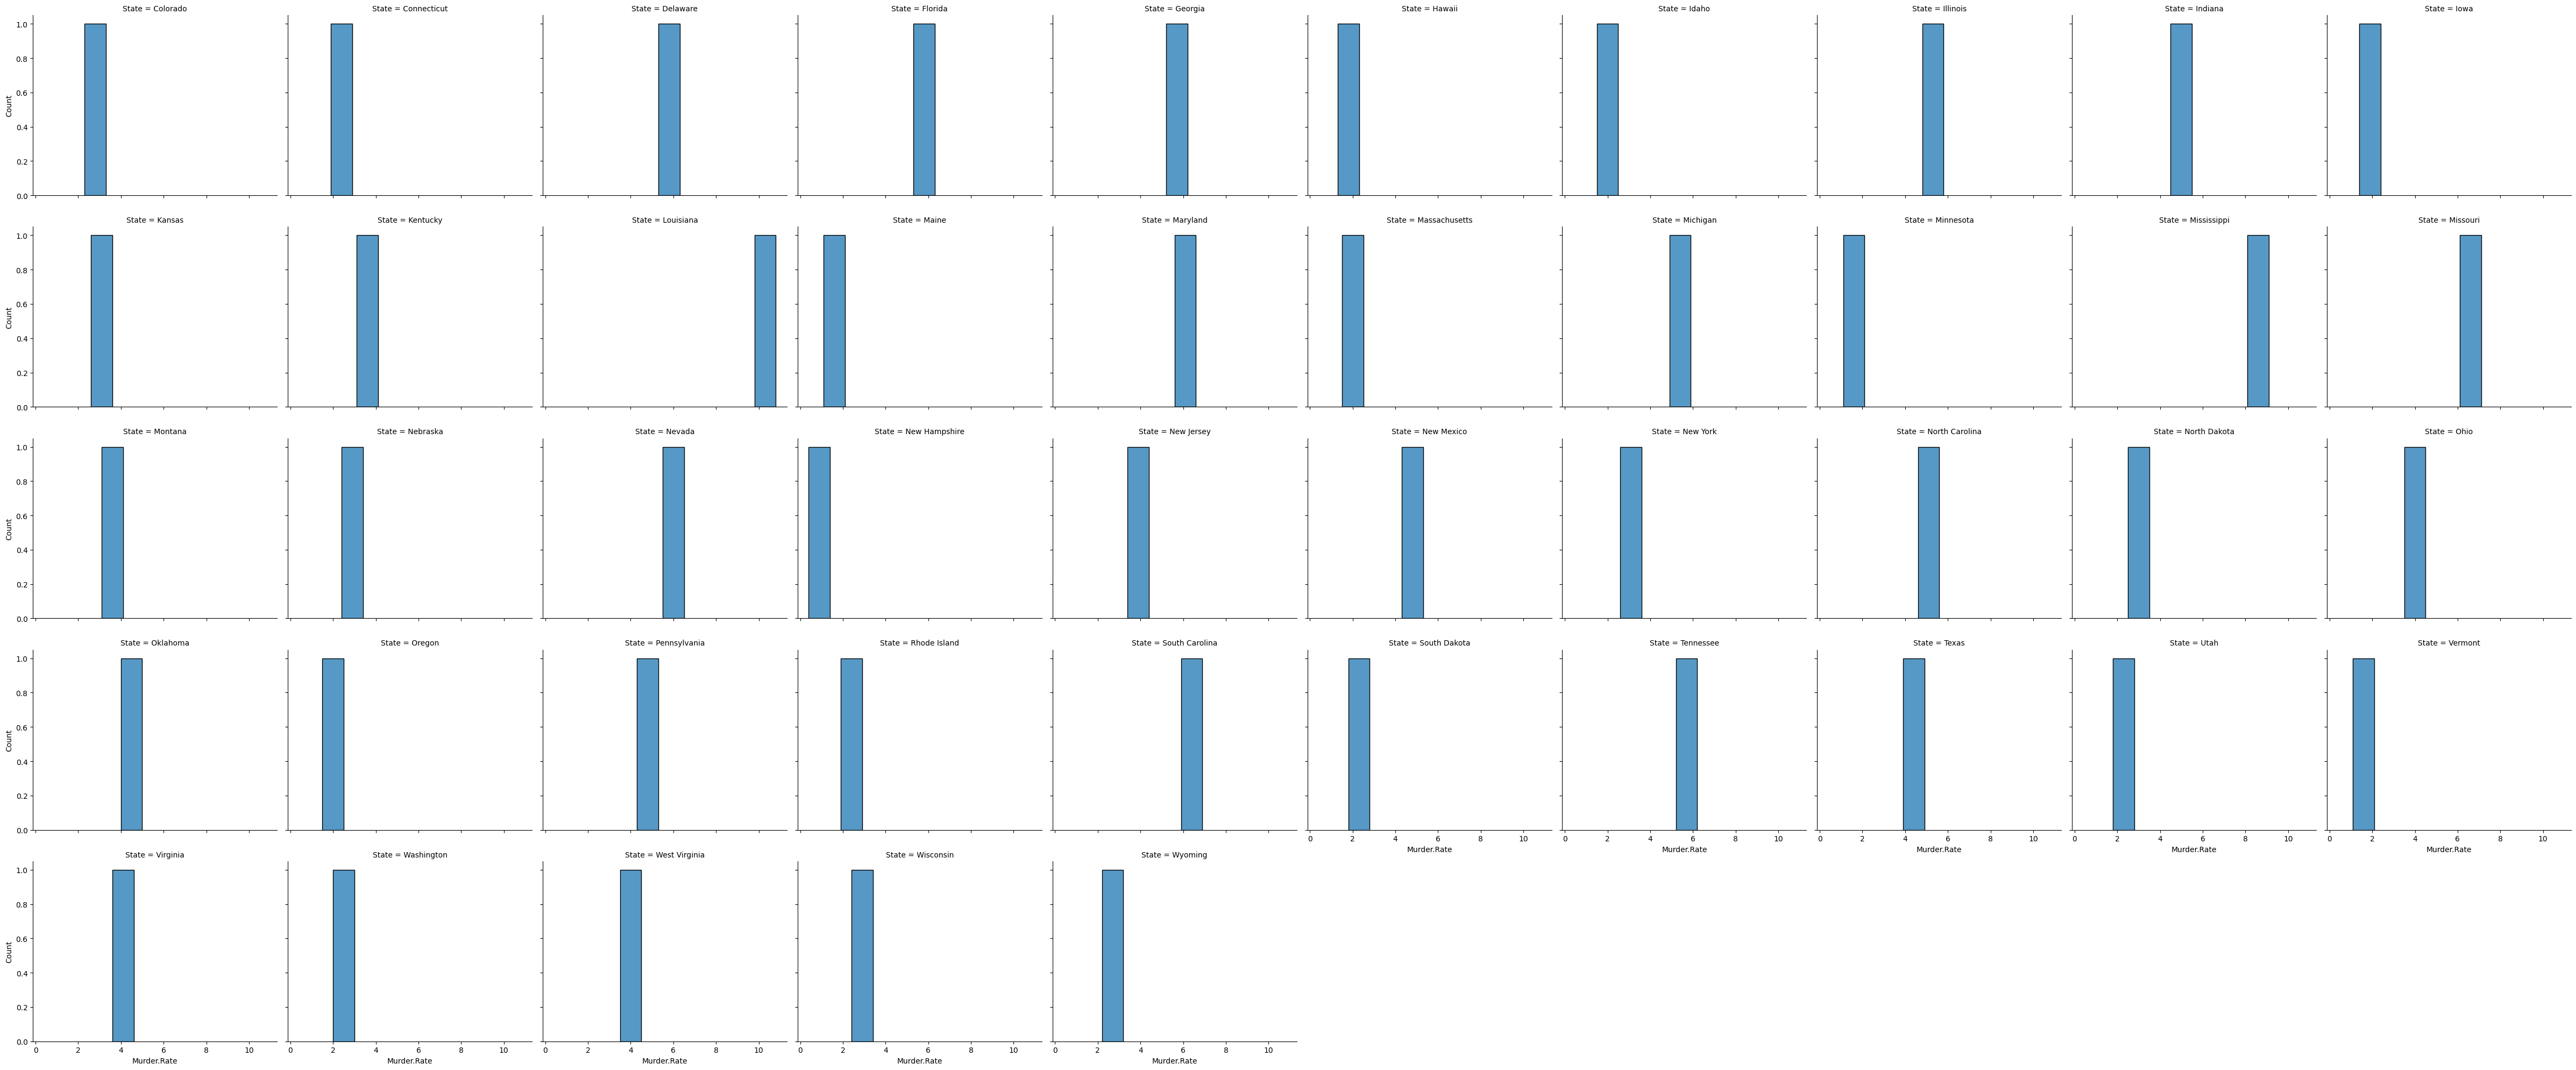

In [ ]:
#TAREA 1

analisis = estado.iloc[5:]
g = sns.FacetGrid(analisis, col="State", col_wrap= 10, height=4, aspect= 1.2)
g.map(sns.histplot, "Murder.Rate")

In [ ]:
#Desviación estándar
estado["Population"].std()

6848235.347401142

In [ ]:
estado["Population"].quantile(0.75)-estado['Population'].quantile(0.25)

np.float64(4847308.0)

#EXPLORACIÓN EN LA DISTRIBUCIÓN DE DATOS
1. Diagrama de caja
2. Diagrama de frecuencias: Registro de recuento de valores de datos numéricos que caen en categorías
3. Histograma: Diagrama de tabla de frecuencias con los inyercalos en el eje x
4. Diagrama de densidad: Versión suavizada del histograma

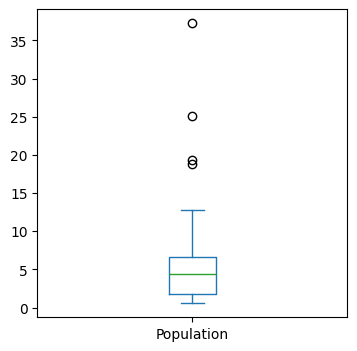

In [ ]:
#TAREA 2

ax=(estado.Population/1_000_000).plot.box(figsize=(4,4))
ax.set_label("Population[millón]")

plt.show()

#TAREA 2 RESPUESTA
En un diagrama de caja y bigotes normalmente hay 5 variables.

1. Mínimo: Es el valor más pequeño que no es outlier y el que marca el inicio del bigote inferior.
2. Primer Quartil (Q1): es el 25% de los datos y el inicio de la caja.
3. Mediana (Q2): Es el valor central que divide los datos en dos partes iguales. Es la línea dentro de la caja.
4. Tercer Quartil (Q3): Es el 75% de los datos y el final de la caja.
5. Máximo: Es el valor más grande que no es outlier y el final del bigote superior.

###Respecto al diagrama anterior

1. La caja azul: representa el 50% central de lo datos (va desde Q1-Q3) y el tamaño de la caja indica qué tan dispersos están los datos centrales
En este caso, como la caja esta baja, la mayoría de los estados tiene poblaciones similares y no muy grandes.

2. La línea verde dentro de la caja: Es la mediana (Q2), la cual, divide los datos en dos mitades iguales. La posición de esta indica si la distribución en simétrica y dirección del sesgo, hacia donde se inclina (centro = simetría, superior = sesgo negativo(dispersión valores bajos), inferior = sesgo positivo (dispersión valores altos))
En este caso, la mediana esta cerca al borde inferior por lo que la distribución no es simétrica con sesgos negativo, es decir, inclinación hacia la izquierda.

3. Líneas que salen de la caja: Son los bigotes, se extienden hasta el mínimo y máximo que no son outliers
Muestran el rango normal de los datos.
El bigote superior es más largo por lo que hay mayor dispersión hacia valores grande.

4. Los circulos: Cada círculo representa un outlier (valor atípico). Son estados con poblaciones mucho más altas que la mayoría. Se dibujan como puntos separados de los bigotes

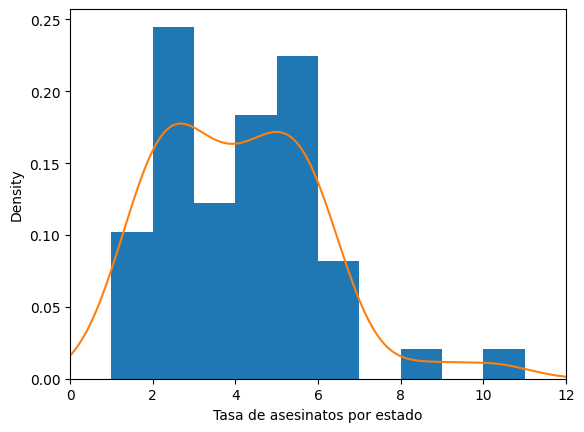

In [ ]:
ax=estado["Murder.Rate"].plot.hist(density =True, xlim=[0,12],bins=range(1,12))
estado["Murder.Rate"].plot.density(ax=ax)
ax.set_xlabel("Tasa de asesinatos por estado")
plt.show()

Sobre estimaciones de variabilidad
1. ¿Qué significa que la desviación estándar es casi dos veces mayor que la MAD?

Significa que los datos presentan valores extremos (outliers) que están influyendo fuertemente en la variabilidad.
La desviación estándar es sensible a valores muy grandes o muy pequeños, mientras que la MAD (desviación absoluta mediana) es más robusta.
Que la desviación estándar sea casi el doble indica que algunos estados tienen tasas de homicidios mucho más altas que el resto, aumentando artificialmente la dispersión.

2. ¿Cómo puedo mejorar esta situación?

Esta situación se puede mejorar:
- Analizando los outliers por separado
- Usando medidas robustas como la mediana y el IQR en lugar de la media y la desviación estándar
- Segmentando los datos en intervalos (por ejemplo, tasas bajas, medias y altas)
- Transformando los datos (por ejemplo, con logaritmos) si el análisis lo permite

3. Explique el resultado obtenido al calcular el IQR

El IQR (rango intercuartílico) representa la diferencia entre el tercer y el primer cuartil (Q3 − Q1).
Este valor indica el rango donde se encuentra el 50% central de los estados en términos de tasa de homicidios.
El resultado muestra que la mayoría de los estados tiene tasas relativamente similares, mientras que los estados fuera de ese rango pueden considerarse valores atípicos.


Sobre exploración en distribución de datos
1. ¿Qué información nos suministran los percentiles de tasa de homicidios por estados?

Los percentiles indican cómo se distribuyen las tasas de homicidio entre los estados.
Permiten saber:

Qué valores separan a los estados con tasas bajas, medias y altas

En qué punto se encuentra un estado respecto al resto

Cómo se acumulan los datos a lo largo de la distribución

2. Explique con sus propias palabras qué información suministra el diagrama de caja

El diagrama de caja muestra:

La mediana de la tasa de homicidios

La dispersión de los datos mediante el IQR

Los valores atípicos, es decir, estados con tasas mucho más altas o bajas que la mayoría

En resumen, permite ver rápidamente la variabilidad, la simetría y la presencia de outliers en la tasa de homicidios por estado.


3. ¿Cómo podrían agregarse los estados en cada intervalo? Interprete los resultados

Los estados pueden agruparse según intervalos definidos por los cuartiles (por ejemplo:
baja, media-baja, media-alta y alta tasa de homicidios).

Al completar la tabla manualmente, se observa que:

La mayoría de los estados se concentra en tasas bajas y medias

Un número reducido de estados presenta tasas altas, lo que explica la asimetría de la distribución

Estos estados con tasas altas influyen significativamente en la media y la desviación estándar

4. Explique el resultado obtenido por el diagrama de dispersión

El diagrama de dispersión permite observar:

La variabilidad de las tasas de homicidios

La presencia de concentraciones de puntos en ciertos rangos

La existencia de estados aislados con tasas muy altas

El resultado evidencia que los datos no están distribuidos uniformemente y que existen estados con comportamientos significativamente distintos al resto.
